In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
dataset_path = "/SeaAnimal/SeaAnimal_Dataset/"

In [4]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    shuffle=True,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32)

validation_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.1,
    shuffle=True,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.1,
    shuffle=True,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32)

Found 13712 files belonging to 23 classes.
Using 10970 files for training.
Found 13712 files belonging to 23 classes.
Using 1371 files for validation.
Found 13712 files belonging to 23 classes.
Using 1371 files for validation.


In [5]:
class_name = train_data.class_names

In [6]:
from tensorflow import keras
from tensorflow.keras import layers

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horinzontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


train_data = train_data.map(lambda x, y: (data_augmentation(x, training=True), y))

In [8]:
from tensorflow.keras.applications.resnet50 import preprocess_input
train_data = train_data.map(lambda image, label: (preprocess_input(image), label))
validation_data = validation_data.map(lambda image, label: (preprocess_input(image), label))

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

base_model = applications.ResNet50(
    weights="imagenet",
    input_shape=(224, 224, 3),
    include_top=False)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),

    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(23, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 23)                  │           5,911 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,777,111 (94.52 MB)

 Trainable params: 1,187,863 (4.53 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

In [11]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=50,
    batch_size = 32,
)

Epoch 1/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 1098s 3s/step - accuracy: 0.4133 - loss: 2.1367 - val_accuracy: 0.7061 - val_loss: 1.0109
Epoch 2/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 1013s 3s/step - accuracy: 0.6317 - loss: 1.2708 - val_accuracy: 0.7571 - val_loss: 0.8181
Epoch 3/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 576s 2s/step - accuracy: 0.6875 - loss: 1.0610 - val_accuracy: 0.7812 - val_loss: 0.7639
Epoch 4/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 531s 2s/step - accuracy: 0.7142 - loss: 0.9658 - val_accuracy: 0.7863 - val_loss: 0.7398
Epoch 5/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 488s 1s/step - accuracy: 0.7372 - loss: 0.8848 - val_accuracy: 0.7921 - val_loss: 0.7175
Epoch 6/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 488s 1s/step - accuracy: 0.7496 - loss: 0.8291 - val_accuracy: 0.7958 - val_loss: 0.6963
Epoch 7/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 488s 1s/step - accuracy: 0.7609 - loss: 0.7861 - val_accuracy: 0.8053 - val_loss: 0.6887
Epoch 8/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 487s 1s/step - accuracy: 0.7727 - loss: 0.7429 - val_ac

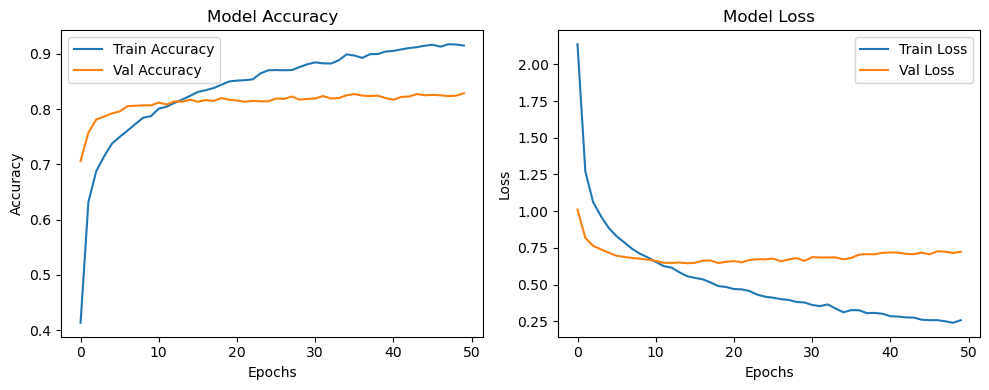

In [12]:
 plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


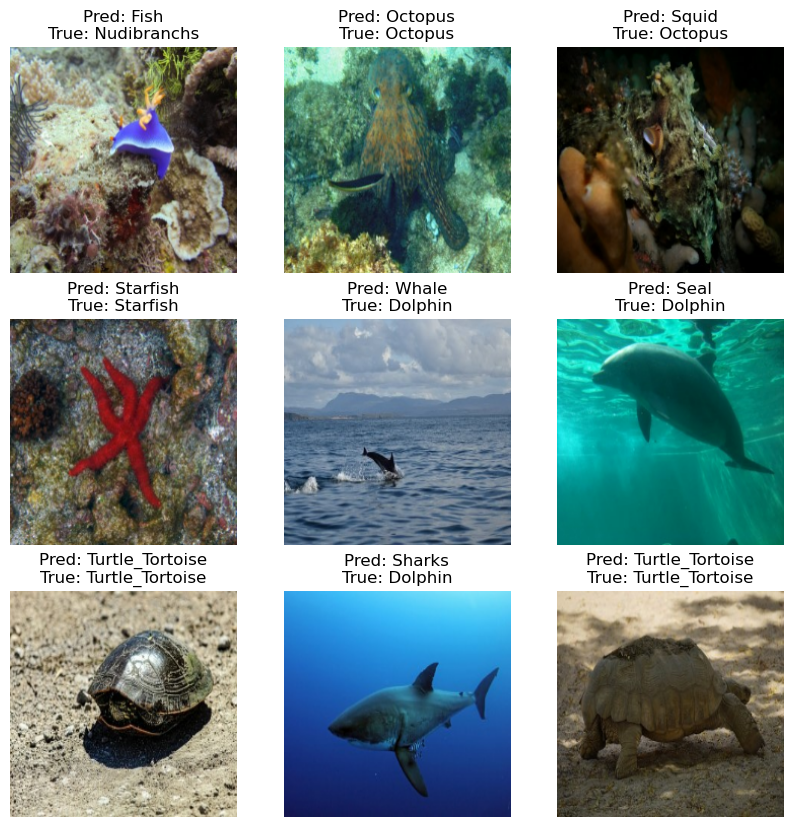

In [13]:
#Predict Values
plt.figure(figsize=(10, 10))

for images, labels in test_data.take(1):  
    
    predictions = model.predict(images)  

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8")) 
        predicted_label = np.argmax(predictions[i])  
        true_label = labels[i]  

        plt.title(f"Pred: {class_name[predicted_label]}\nTrue: {class_name[true_label]}")
        plt.axis("off")